## Square

In [63]:
include("../QMC.jl")
include("../QMC_plot.jl")
include("../Lattice.jl")

kagome (generic function with 1 method)

In [64]:
L = 3
H = 3
n = H*L
cc = (i,j) -> mod( mod(j+H, H)*L + mod(i+L,L), n) + 1
cc(1,0)

2

In [65]:
get(reverse(ColorSchemes.colorschemes[:RdYlBu]), 0)
reverse(ColorSchemes.colorschemes[:diverging_linear_bjy_30_90_c45_n256])
reverse(ColorSchemes.colorschemes[:RdYlBu])

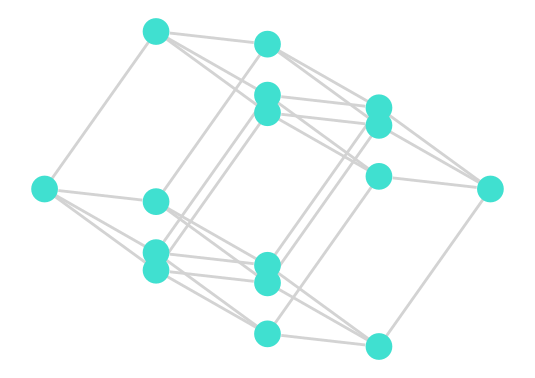

In [66]:
A = Square(4,4;J=1, periodic=true)
g = Graphs.SimpleGraph(A)
import GraphPlot
GraphPlot.gplot(g, layout=GraphPlot.spectral_layout)

## Square energies

In [67]:
import Cairo # Cairo is needed for Compose.PDF
import Compose #import Cairo

J = 1
l = h = 4
J_diag = 1
# open boundary lattice only for plotting

A =      square(l,h; J=J, periodic=true); # only for plotting
A_open = square(l,h; J=J, periodic=false); 

-23.999999937454447

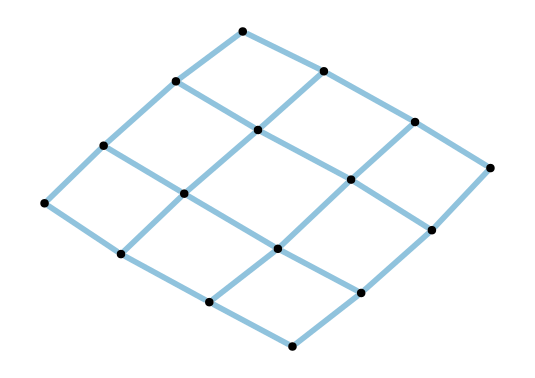

In [68]:
val, X = QMC_SOC(A, verbose=false, pauli_NPA1=false)
plot = QMC_Plot(A_open,X)
name = "Square" * string(l) * string(h) * "_" * string(J) * ".pdf"
Compose.draw(Compose.PDF(name, 16Compose.cm, 16Compose.cm), plot) #print to file
print(val); plot